# Лабораторная работа №1  
## Классический жизненный цикл разработки моделей машинного обучения

**Вариант:** 4  
**Датасет:** Housing Values in Suburbs of Boston  
**Целевая переменная:** `medv`  
**Тип задачи:** регрессия  
**Основная метрика:** RMSE

### Цель текущего этапа
На этом этапе в Google Colab выполняется первичная реализация ML-решения:
- загрузка локально скачанных данных;
- первичный анализ данных;
- подготовка признаков;
- обучение и сравнение нескольких регрессионных моделей;
- выбор базового решения для дальнейшего переноса в production-like репозиторий.

### Что нужно загрузить в Colab
Перед запуском ноутбука подготовь одну из двух опций:

**Опция A — рекомендую:** ZIP-архив с файлами:
- `train.csv`
- `test.csv`
- `submission_example.csv`

**Опция B:** загрузить эти три CSV-файла по отдельности.

In [5]:
# Базовые импорты
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "medv"

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Импорты выполнены успешно.")

Импорты выполнены успешно.


## 1. Загрузка локальных данных

Так как датасет уже скачан на компьютер, Kaggle API здесь **не используется**.

После запуска следующей ячейки:
1. загрузи **ZIP-архив** с датасетом **или**
2. загрузи сразу три файла:
   - `train.csv`
   - `test.csv`
   - `submission_example.csv`

In [6]:
uploaded = files.upload()

print("Загруженные файлы:")
for name in uploaded.keys():
    print("-", name)

Saving submission_example.csv to submission_example.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
Загруженные файлы:
- submission_example.csv
- test.csv
- train.csv


## 2. Подготовка рабочей папки

Если был загружен ZIP, он будет распакован.  
Если были загружены CSV, они будут перемещены в рабочую папку `boston-housing-data`.

In [7]:
workspace_dir = Path("boston-housing-data")
workspace_dir.mkdir(parents=True, exist_ok=True)

uploaded_filenames = list(uploaded.keys())
zip_files = [f for f in uploaded_filenames if f.lower().endswith(".zip")]
csv_files = [f for f in uploaded_filenames if f.lower().endswith(".csv")]

if zip_files:
    zip_name = zip_files[0]
    with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall(workspace_dir)
    print(f"Архив {zip_name} распакован в {workspace_dir.resolve()}")
else:
    for csv_name in csv_files:
        shutil.move(csv_name, workspace_dir / csv_name)
    print(f"CSV-файлы перемещены в {workspace_dir.resolve()}")

print("\nСодержимое рабочей папки:")
for p in sorted(workspace_dir.iterdir()):
    print("-", p.name)

CSV-файлы перемещены в /content/boston-housing-data

Содержимое рабочей папки:
- __MACOSX
- boston-housing
- submission_example.csv
- test.csv
- train.csv


## 3. Проверка наличия нужных файлов

In [8]:
train_path = workspace_dir / "train.csv"
test_path = workspace_dir / "test.csv"
submission_example_path = workspace_dir / "submission_example.csv"

required_files = [train_path, test_path, submission_example_path]

for file_path in required_files:
    print(file_path.name, "->", "OK" if file_path.exists() else "НЕ НАЙДЕН")

missing_files = [p.name for p in required_files if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "Не найдены обязательные файлы: "
        + ", ".join(missing_files)
        + ". Проверь названия файлов внутри папки или архива."
    )

train.csv -> OK
test.csv -> OK
submission_example.csv -> OK


## 4. Загрузка данных

In [9]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
submission_example_df = pd.read_csv(submission_example_path)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("submission_example shape:", submission_example_df.shape)

display(train_df.head())
display(test_df.head())
display(submission_example_df.head())

train shape: (333, 15)
test shape: (173, 14)
submission_example shape: (173, 2)


,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
1,6,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21
2,8,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15
3,9,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93
4,10,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10


,ID,medv
0,3,22.768769
1,6,22.768769
2,8,22.768769
3,9,22.768769
4,10,22.768769


## 5. Первичный обзор данных

На этом шаге проверяем:
- названия столбцов;
- типы данных;
- наличие пропусков;
- базовую статистику;
- наличие целевой переменной `medv`.

In [10]:
print("Колонки train:")
print(train_df.columns.tolist())
print()

print("Типы данных:")
display(train_df.dtypes.to_frame("dtype"))

print("Пропуски в train:")
display(train_df.isna().sum().to_frame("missing_count"))

print("Описательная статистика:")
display(train_df.describe().T)

Колонки train:
['ID', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv']

Типы данных:


,dtype
ID,int64
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64


Пропуски в train:


,missing_count
ID,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0


Описательная статистика:


,count,mean,std,min,25%,50%,75%,max
ID,333.0,250.951952,147.859438,1.00000,123.00000,244.00000,377.00000,506.0000
crim,333.0,3.360341,7.352272,0.00632,0.07896,0.26169,3.67822,73.5341
zn,333.0,10.689189,22.674762,0.00000,0.00000,0.00000,12.50000,100.0000
indus,333.0,11.293483,6.998123,0.74000,5.13000,9.90000,18.10000,27.7400
chas,333.0,0.060060,0.237956,0.00000,0.00000,0.00000,0.00000,1.0000
nox,333.0,0.557144,0.114955,0.38500,0.45300,0.53800,0.63100,0.8710
rm,333.0,6.265619,0.703952,3.56100,5.88400,6.20200,6.59500,8.7250
age,333.0,68.226426,28.133344,6.00000,45.40000,76.70000,93.80000,100.0000
dis,333.0,3.709934,1.981123,1.12960,2.12240,3.09230,5.11670,10.7103
rad,333.0,9.633634,8.742174,1.00000,4.00000,5.00000,24.00000,24.0000


## 6. Проверка целевой переменной

Для задачи регрессии важно отдельно посмотреть распределение `medv`, чтобы понять:
- форму распределения;
- наличие выбросов;
- есть ли смысл в дальнейшем пробовать преобразования таргета.

На первом этапе используем `medv` без преобразования.

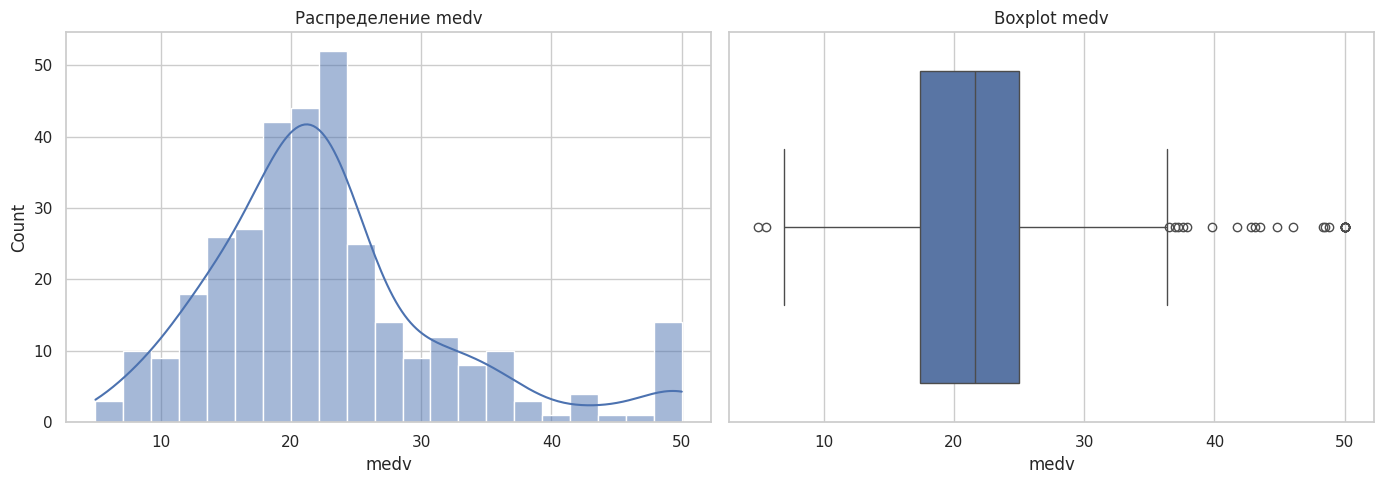

In [11]:
if TARGET_COL not in train_df.columns:
    raise ValueError(f"В train.csv не найдена целевая переменная {TARGET_COL}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df[TARGET_COL], kde=True, ax=axes[0])
axes[0].set_title("Распределение medv")

sns.boxplot(x=train_df[TARGET_COL], ax=axes[1])
axes[1].set_title("Boxplot medv")

plt.tight_layout()
plt.show()

## 7. Корреляционный анализ

Строим:
- корреляционную матрицу;
- список корреляций признаков с `medv`.

Это даст хорошую основу для краткого EDA в отчёте.

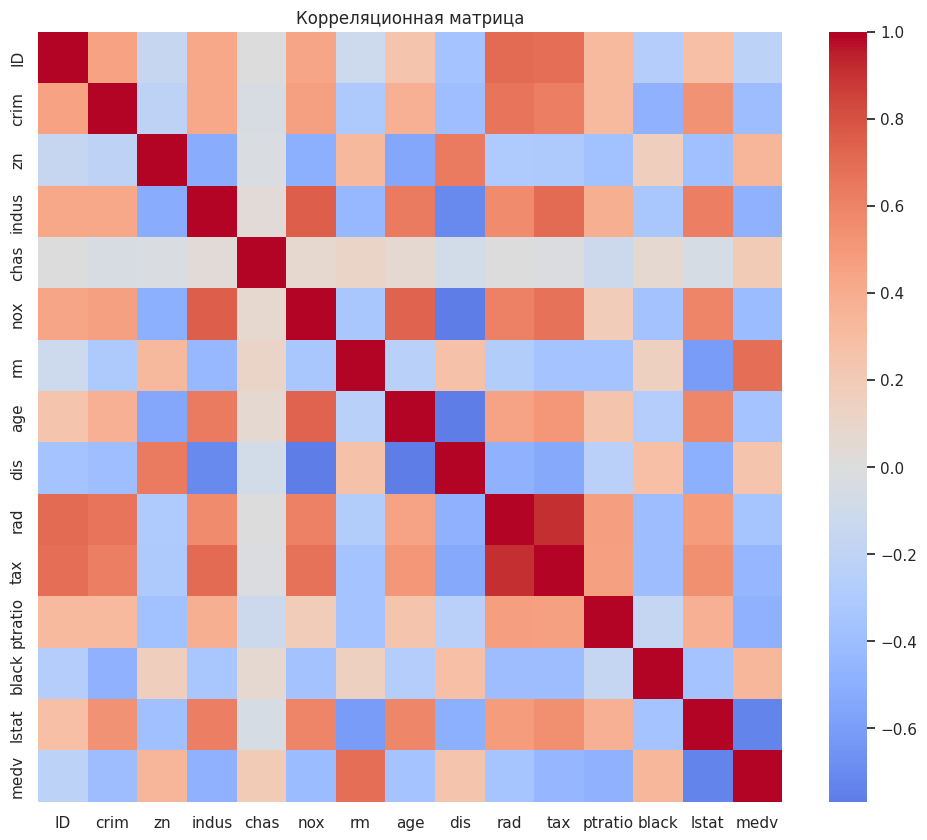

Корреляция признаков с medv:


,correlation_with_medv
medv,1.000000
rm,0.689598
zn,0.344842
black,0.336660
dis,0.249422
chas,0.204390
ID,-0.221694
rad,-0.352251
age,-0.358888
crim,-0.407454


In [12]:
corr = train_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица")
plt.show()

target_corr = corr[TARGET_COL].sort_values(ascending=False)
print("Корреляция признаков с medv:")
display(target_corr.to_frame("correlation_with_medv"))

## 8. Небольшой визуальный EDA по ключевым признакам

Для учебной лабораторной достаточно показать несколько зависимостей:
- `rm` vs `medv`
- `lstat` vs `medv`
- `ptratio` vs `medv`

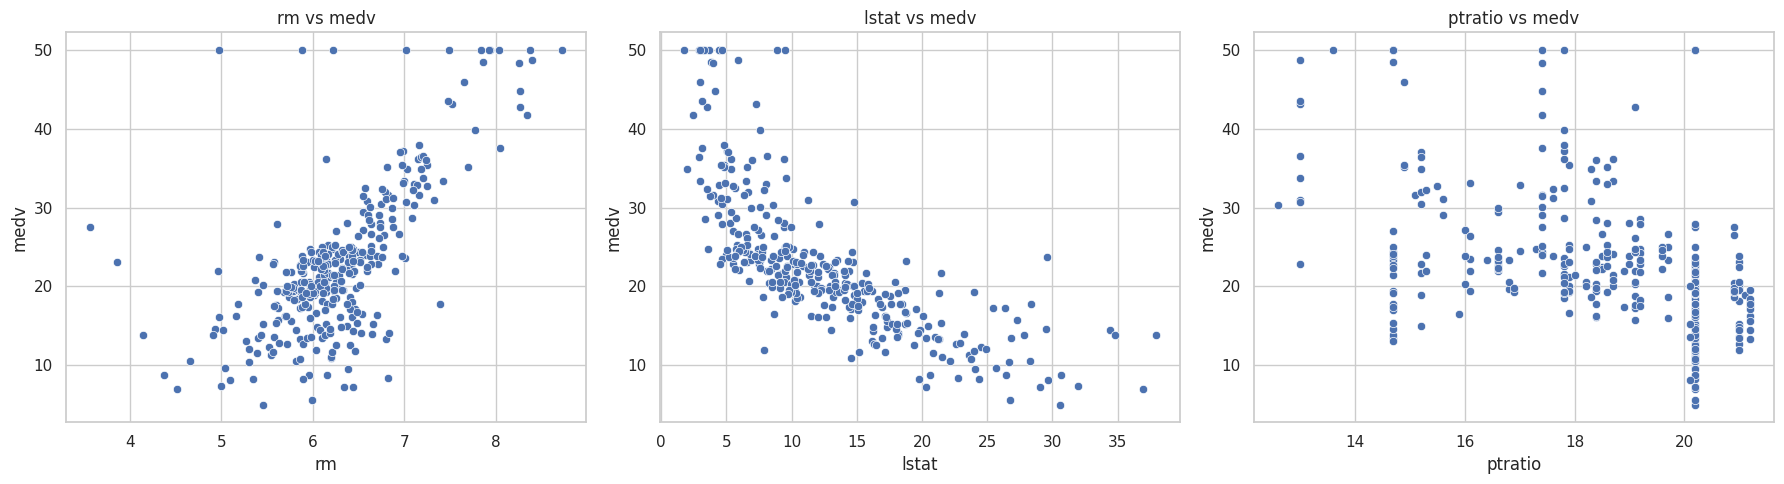

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=train_df, x="rm", y="medv", ax=axes[0])
axes[0].set_title("rm vs medv")

sns.scatterplot(data=train_df, x="lstat", y="medv", ax=axes[1])
axes[1].set_title("lstat vs medv")

sns.scatterplot(data=train_df, x="ptratio", y="medv", ax=axes[2])
axes[2].set_title("ptratio vs medv")

plt.tight_layout()
plt.show()

## 9. Подготовка данных к обучению

Разделяем данные на признаки `X` и целевую переменную `y`, затем делаем train/validation split.

### Модели для сравнения
1. **LinearRegression** — baseline.
2. **Ridge** — улучшенная линейная модель с регуляризацией.
3. **RandomForestRegressor** — нелинейная альтернатива.

### Подход к scaling
- для `LinearRegression` и `Ridge` scaling нужен;
- для `RandomForestRegressor` scaling не обязателен.

In [14]:
X = train_df.drop(columns=[TARGET_COL])
y = train_df[TARGET_COL]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

numeric_features = X.columns.tolist()
print("Признаки:", numeric_features)

X_train: (266, 14)
X_valid: (67, 14)
y_train: (266,)
y_valid: (67,)
Признаки: ['ID', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat']


## 10. Метрика RMSE

Основная метрика соревнования и лабораторной — RMSE.  
Ниже определяем отдельную функцию, которую потом будет удобно перенести в `src/evaluate.py`.

In [15]:
def rmse_score(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

print("Проверка RMSE функции:", rmse_score([1, 2, 3], [1, 2, 3]))

Проверка RMSE функции: 0.0


## 11. Пайплайны предобработки

Так как все признаки числовые, базовая предобработка будет такой:
- заполнение пропусков медианой;
- масштабирование для линейных моделей;
- без масштабирования для Random Forest.

In [16]:
linear_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

tree_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

linear_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
}

tree_models = {
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
}

## 12. Обучение и оценка моделей

In [17]:
results = []
trained_pipelines = {}

for model_name, model in linear_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)
    score = rmse_score(y_valid, preds)

    results.append({
        "model": model_name,
        "rmse": score,
    })
    trained_pipelines[model_name] = pipeline

for model_name, model in tree_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_valid)
    score = rmse_score(y_valid, preds)

    results.append({
        "model": model_name,
        "rmse": score,
    })
    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
display(results_df)

,model,rmse
0,RandomForestRegressor,2.815619
1,Ridge,4.819884
2,LinearRegression,4.838564


## 13. Выбор лучшей модели

In [18]:
best_model_name = results_df.iloc[0]["model"]
best_rmse = results_df.iloc[0]["rmse"]

print(f"Лучшая модель на validation: {best_model_name}")
print(f"Лучший RMSE: {best_rmse:.4f}")

Лучшая модель на validation: RandomForestRegressor
Лучший RMSE: 2.8156


## 14. Переобучение лучшей модели на полном train

После выбора лучшей модели переобучаем её на всём `train.csv`.  
Это пригодится для:
- генерации предсказаний для `test.csv`;
- следующего этапа, где мы будем переносить логику в `src/`;
- последующего сохранения модели.

In [19]:
if best_model_name == "LinearRegression":
    best_pipeline = Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", LinearRegression()),
        ]
    )
elif best_model_name == "Ridge":
    best_pipeline = Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", Ridge(alpha=1.0)),
        ]
    )
else:
    best_pipeline = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]
    )

best_pipeline.fit(X, y)
print("Лучшая модель переобучена на полном train.")

Лучшая модель переобучена на полном train.


## 15. Предсказания для test.csv

Проверяем полный inference pipeline и формируем submission-файл.

In [20]:
test_predictions = best_pipeline.predict(test_df)

print("Количество предсказаний:", len(test_predictions))
print("Первые 10 предсказаний:")
print(test_predictions[:10])

Количество предсказаний: 173
Первые 10 предсказаний:
[33.68266667 24.281      16.36333333 14.98466667 17.55933333 19.055
 20.16933333 15.69933333 15.824      18.25266667]


In [21]:
submission = submission_example_df.copy()

target_like_columns = [col for col in submission.columns if col.lower() != "id"]

if len(target_like_columns) == 1:
    submission[target_like_columns[0]] = test_predictions
else:
    submission["medv"] = test_predictions

display(submission.head())

,ID,medv
0,3,33.682667
1,6,24.281000
2,8,16.363333
3,9,14.984667
4,10,17.559333


In [22]:
submission_path = Path("submission.csv")
submission.to_csv(submission_path, index=False)

print(f"Submission сохранён: {submission_path.resolve()}")

Submission сохранён: /content/submission.csv


## 16. Итоговые выводы

### Что было сделано
- загружены локальные данные Boston Housing;
- выполнен краткий EDA;
- реализована подготовка данных;
- обучены и сравнены несколько регрессионных моделей;
- качество оценено по RMSE;
- выбрана лучшая модель;
- сформирован файл `submission.csv`.

### Что будет дальше
На следующем этапе это решение будет перенесено в структурированный репозиторий:
- логика будет вынесена из ноутбука в `.py`-скрипты;
- будет добавлен API-сервис;
- будут написаны тесты;
- будет подключён DVC;
- будут созданы Docker и CI/CD pipeline.